# 02 - Inteligência de Priorização

Objetivo: transformar o ranking causal de fontes em uma regra operacional que escolha os dois melhores telefones por CPF.

Esta etapa entrega dois artefatos pedidos no enunciado: um ranking matemático de confiabilidade das fontes e um algoritmo operacional de escolha. A métrica primária de escolha é entrega (`delivered` ou `read`); leitura continua monitorada como métrica secundária de negócio. A interpretação de `read` segue a premissa do notebook 01: uma mensagem lida necessariamente foi entregue.

**Definição de champion:** neste notebook, champion é a política candidata para ir ao A/B. A política champion não é necessariamente o modelo estatístico; é o método que teve melhor desempenho de decisão no holdout entre modelo, heurística e baselines simples.

A validação offline abaixo deve ser lida como evidência histórica aproximada, não como prova final de superioridade. Como há viés de seleção e baixa cobertura de alguns telefones no holdout, a decisão definitiva fica para o A/B do notebook 03.

**Limitação importante:** A validação offline tem limitações inerentes — o holdout cobre apenas ~18% dos CPFs com histórico por telefone. Os resultados devem ser interpretados como indicativos, não como conclusivos.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler

import utils as u

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Imports OK')


Imports OK


## 1. Dados, aparições e split temporal


In [2]:
df_disparo_raw, df_telefone_raw = u.carregar_dados()

df_disparo = u.filtrar_status_invalidos(df_disparo_raw)
df_telefone = u.filtrar_telefones_fixos(df_telefone_raw)
df_disparo['envio_datahora'] = pd.to_datetime(df_disparo['envio_datahora'])
df_disparo = df_disparo.sort_values('envio_datahora').reset_index(drop=True)

df_aparicoes_brutas = u.explodir_aparicoes(df_telefone)
df_aparicoes_fonte = u.preparar_aparicoes_por_fonte(df_aparicoes_brutas)
df_phone_cpf = u.preparar_telefone_cpf(df_aparicoes_brutas)
df_phone_meta = u.preparar_metadados_telefone(df_telefone, df_aparicoes_fonte, df_aparicoes_brutas)

splits = u.criar_splits_temporais(df_disparo, frac_treino=0.60, frac_tuning=0.20)
df_train_disparo = splits['treino']
df_tune_disparo = splits['tuning']
df_test_disparo = splits['teste']
df_dev_disparo = pd.concat([df_train_disparo, df_tune_disparo], ignore_index=True)
cutoff_tuning = splits['cutoff_tuning']
cutoff_teste = splits['cutoff_teste']

print('Periodo observado:', df_disparo['envio_datahora'].min(), '->', df_disparo['envio_datahora'].max())
print('Cutoff tuning:', cutoff_tuning)
print('Cutoff teste:', cutoff_teste)
print('Treino:', len(df_train_disparo))
print('Tuning:', len(df_tune_disparo))
print('Teste:', len(df_test_disparo))


Filtrando status intermediários: 392,921 -> 389,761 (-3,160)
Filtrando telefones fixos: 283,289 -> 283,281 (-8)
Telefones únicos: 283,281
Aparições brutas: 1,522,742
Sistemas únicos: 6
Aparições por fonte deduplicadas: 669,522
Pares telefone-CPF candidatos: 1,246,889
Periodo observado: 2025-09-03 09:43:05 -> 2026-04-18 14:28:19
Cutoff tuning: 2026-02-11 07:49:48
Cutoff teste: 2026-03-24 09:29:19.878000
Treino: 233856
Tuning: 77952
Teste: 77953


## 2. Ranking causal de sistemas aprendido no treino

O ranking usa somente informação disponível antes do envio. Para cada sistema, calculamos:

`taxa_entrega = (read + delivered) / total_disparos`

`score_sistema = min_max(EmpiricalBayesLowerBound(entregas, total_disparos))`

Matematicamente, um sistema X fica acima de um sistema Y quando seu limite inferior beta-binomial (`eb_lower_entrega`) é maior. Esse critério combina taxa observada e incerteza amostral: duas fontes com a mesma taxa bruta podem ter pontuações diferentes se uma delas tiver menos volume. O ranking principal usa o limite inferior beta-binomial empírico, que encolhe fontes pequenas para a média global e funciona melhor com atribuição fracionária. O Wilson lower bound continua reportado como diagnóstico comparável.

Para leitura visual, os IDs podem ser abreviados no texto pelos primeiros caracteres (por exemplo, `-4704...`), mas as tabelas mantêm o identificador completo para rastreabilidade.

Disparos com match: 213,047 / 233,856
Total de linhas após join: 442,691
Multiplicidade média: 2.08x


,id_sistema,total_disparos,sucessos_entrega,taxa_entrega,taxa_leitura,eb_lower_entrega,posterior_mean_entrega,wilson_lower_entrega,score_sistema
0,-4704067261970591609,162722.0,161776.0,0.994186,0.780165,0.993773,0.994149,0.993805,1.000000
1,-2757366171786647144,3835.0,3729.0,0.972360,0.716297,0.966627,0.971939,0.966680,0.514815
2,3094574413675758272,158264.0,150263.0,0.949445,0.738620,0.948380,0.949463,0.948355,0.188691
3,4458959843028638627,12837.0,12197.0,0.950144,0.721041,0.946561,0.950355,0.946243,0.156195
4,-133612832286195827,12605.0,11913.0,0.945101,0.734708,0.941394,0.945394,0.940987,0.063835
5,1257277410380486863,92428.0,86819.0,0.939315,0.710542,0.937822,0.939368,0.937757,0.000000


metodo_atribuicao,fonte_mais_recente,fracionario,full
id_sistema,,,
-133612832286195827,0.000000,0.002378,0.063835
-2757366171786647144,0.687984,0.540817,0.514815
-4704067261970591609,1.000000,1.000000,1.000000
1257277410380486863,0.458143,0.000000,0.000000
3094574413675758272,0.787498,0.219915,0.188691
4458959843028638627,0.473722,0.240253,0.156195


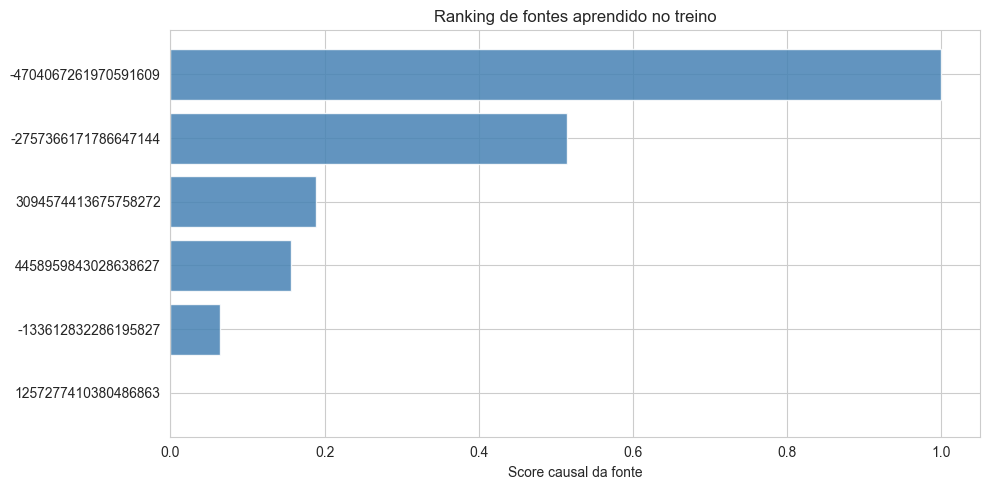

In [3]:
metricas_sistema_train, df_train_sistema = u.aprender_ranking_sistemas(
    df_train_disparo, df_aparicoes_fonte,
    metodo_atribuicao='full', metodo_ranking='empirical_bayes'
)

rankings_sensibilidade = []
for metodo_atribuicao in ['full', 'fracionario', 'fonte_mais_recente']:
    metricas_tmp = u.calcular_score_sistema(
        u.calcular_metricas_sistema(df_train_sistema, metodo_atribuicao=metodo_atribuicao),
        metodo_ranking='empirical_bayes'
    )
    rankings_sensibilidade.append(metricas_tmp.assign(metodo_atribuicao=metodo_atribuicao))
rankings_sensibilidade = pd.concat(rankings_sensibilidade, ignore_index=True)

display(metricas_sistema_train[[
    'id_sistema', 'total_disparos', 'sucessos_entrega', 'taxa_entrega',
    'taxa_leitura', 'eb_lower_entrega', 'posterior_mean_entrega',
    'wilson_lower_entrega', 'score_sistema'
]])
display(rankings_sensibilidade.pivot_table(index='id_sistema', columns='metodo_atribuicao', values='score_sistema'))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = metricas_sistema_train.sort_values('score_sistema')
ax.barh(plot_df['id_sistema'].astype(str), plot_df['score_sistema'], color='steelblue', alpha=0.85)
ax.set_xlabel('Score causal da fonte')
ax.set_title('Ranking de fontes aprendido no treino')
plt.tight_layout()
plt.show()


## 3. Base de eventos e grid search do half-life

A recência entra via decaimento exponencial:

`decaimento = exp(-ln(2) * dias_desde_atualizacao / half_life)`

`score_aparicao = score_sistema * decaimento`

Aparições futuras ou sem data não contribuem para score de origem, quantidade de sistemas causais ou decaimento. Elas recebem `dias_desde_atualizacao = 9999` apenas para manter a penalização operacional explícita.

O half-life é escolhido no período de tuning. O teste temporal fica isolado para a comparação offline final, reduzindo inflação por escolha de hiperparâmetro.

In [4]:
df_aparicoes_train_score = u.anexar_score_sistema(df_aparicoes_fonte, metricas_sistema_train)
resultados_grid = []

for half_life in u.HALF_LIFE_GRID:
    df_eventos_hl = u.montar_eventos(df_dev_disparo, df_aparicoes_train_score, df_phone_meta, half_life)
    df_train_modelo, df_tune_modelo, _, prior_ddd_hl, baseline_ddd_hl = u.preparar_matrizes_modelo(df_eventos_hl, cutoff_tuning)

    X_train = df_train_modelo[u.FEATURE_COLS].fillna(0)
    X_tune = df_tune_modelo[u.FEATURE_COLS].fillna(0)
    y_train = df_train_modelo['y_entrega']
    y_tune = df_tune_modelo['y_entrega']

    scaler_hl = StandardScaler()
    X_train_s = scaler_hl.fit_transform(X_train)
    X_tune_s = scaler_hl.transform(X_tune)

    modelo_hl = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=u.SEED)
    modelo_hl.fit(X_train_s, y_train)
    y_proba_tune = modelo_hl.predict_proba(X_tune_s)[:, 1]

    resultados_grid.append({
        'half_life': half_life,
        'auc_entrega_tuning': roc_auc_score(y_tune, y_proba_tune),
        'log_loss_entrega_tuning': log_loss(y_tune, y_proba_tune),
        'brier_entrega_tuning': brier_score_loss(y_tune, y_proba_tune),
    })

df_grid = pd.DataFrame(resultados_grid)
df_grid['rank_auc'] = df_grid['auc_entrega_tuning'].rank(ascending=False)
df_grid['rank_log_loss'] = df_grid['log_loss_entrega_tuning'].rank(ascending=True)
df_grid['rank_brier'] = df_grid['brier_entrega_tuning'].rank(ascending=True)
df_grid['rank_medio'] = df_grid[['rank_auc', 'rank_log_loss', 'rank_brier']].mean(axis=1)
BEST_HALF_LIFE = int(df_grid.loc[df_grid['rank_medio'].idxmin(), 'half_life'])

display(df_grid.sort_values('rank_medio'))
print('Half-life escolhido:', BEST_HALF_LIFE)


,half_life,auc_entrega_tuning,log_loss_entrega_tuning,brier_entrega_tuning,rank_auc,rank_log_loss,rank_brier,rank_medio
2,90,0.710705,0.233874,0.061855,1.0,1.0,3.0,1.666667
1,60,0.710009,0.233963,0.061558,3.0,2.0,2.0,2.333333
3,120,0.710016,0.234249,0.062191,2.0,4.0,4.0,3.333333
0,30,0.707886,0.234048,0.061170,7.0,3.0,1.0,3.666667
4,180,0.709039,0.234556,0.062587,4.0,5.0,5.0,4.666667
5,270,0.708360,0.235036,0.062931,5.0,7.0,6.0,6.000000
6,365,0.708140,0.234676,0.062971,6.0,6.0,7.0,6.333333


Half-life escolhido: 90


## 4. Modelo preditivo: validação temporal

Esta seção avalia apenas a capacidade preditiva do modelo logístico em ordenar eventos por probabilidade de entrega. As métricas AUC, log loss e Brier respondem à pergunta "o score prevê entrega?". A próxima seção responde outra pergunta: "usar esse score para escolher top-2 telefones por CPF melhora a política de envio?". Separar essas duas avaliações evita confundir bom desempenho preditivo com boa decisão operacional.

In [5]:
metricas_sistema_dev, df_dev_sistema = u.aprender_ranking_sistemas(
    df_dev_disparo, df_aparicoes_fonte,
    metodo_atribuicao='full', metodo_ranking='empirical_bayes'
)
df_aparicoes_dev_score = u.anexar_score_sistema(df_aparicoes_fonte, metricas_sistema_dev)
df_eventos_best = u.montar_eventos(df_disparo, df_aparicoes_dev_score, df_phone_meta, BEST_HALF_LIFE)
df_train_modelo, df_val_modelo, _, prior_ddd_train, baseline_ddd_train = u.preparar_matrizes_modelo(df_eventos_best, cutoff_teste)

X_train = df_train_modelo[u.FEATURE_COLS].fillna(0)
X_val = df_val_modelo[u.FEATURE_COLS].fillna(0)
y_train = df_train_modelo['y_entrega']
y_val = df_val_modelo['y_entrega']

scaler_validacao = StandardScaler()
X_train_s = scaler_validacao.fit_transform(X_train)
X_val_s = scaler_validacao.transform(X_val)

modelo_validacao = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=u.SEED)
modelo_validacao.fit(X_train_s, y_train)
y_proba_val = modelo_validacao.predict_proba(X_val_s)[:, 1]
df_val_modelo['score_modelo_validacao'] = y_proba_val

metricas_validacao = {
    'auc_entrega': roc_auc_score(df_val_modelo['y_entrega'], y_proba_val),
    'log_loss_entrega': log_loss(df_val_modelo['y_entrega'], y_proba_val),
    'brier_entrega': brier_score_loss(df_val_modelo['y_entrega'], y_proba_val),
    'taxa_entrega_teste': df_val_modelo['y_entrega'].mean(),
    'taxa_read_teste': df_val_modelo['y_read'].mean(),
    'taxa_read_top_decile': df_val_modelo.sort_values('score_modelo_validacao', ascending=False).head(max(1, int(len(df_val_modelo) * 0.10)))['y_read'].mean(),
}

for chave, valor in metricas_validacao.items():
    print(f'{chave}: {valor:.4f}')

coef_df = pd.DataFrame({'feature': u.FEATURE_COLS, 'coef_padronizado': modelo_validacao.coef_[0]}).sort_values('coef_padronizado', ascending=False)
display(coef_df)


Disparos com match: 275,415 / 311,808
Total de linhas após join: 551,210
Multiplicidade média: 2.00x
auc_entrega: 0.6624
log_loss_entrega: 0.2662
brier_entrega: 0.0674
taxa_entrega_teste: 0.9467
taxa_read_teste: 0.7035
taxa_read_top_decile: 0.7435


,feature,coef_padronizado
1,melhor_score_sistema,1.513007
12,log_n_sistemas_telefone,0.641029
6,penalidade_proprietarios,0.157069
10,score_exclusividade_cpf,0.157069
5,decaimento_medio,0.119572
4,decaimento_fonte_mais_recente,0.099417
2,melhor_decaimento,0.099417
11,log_cpfs_distintos_telefone,0.073213
7,score_ddd,0.030341
8,is_ddd_21,0.000000


## 5. Algoritmo de escolha e validação offline

O algoritmo combina origem, atualidade, qualidade do telefone e DDD em um score por telefone. A regra heurística final é:

`score_heurístico = 0.35 * origem_tempo + 0.15 * DDD + 0.10 * fonte_mais_recente + 0.10 * proprietários + 0.10 * exclusividade_cpf + 0.08 * qualidade + 0.05 * recência + 0.04 * sistemas + 0.03 * causalidade`

Os pesos são intencionalmente arbitrários (`u.PESOS_HEURISTICA_NOTA`): servem apenas como baseline comparativo para o modelo logístico, não como afirmação sobre a importância relativa dos fatores.

Para cada CPF elegível, selecionamos os dois telefones de maior score. Os desempates são: maior score secundário, menor idade do dado e menor identificador de telefone. A simulação offline compara modelo, heurística, telefone mais recente, fonte mais recente, regra alfabética e random. Além da média dos métodos, uso bootstrap pareado por CPF para estimar a incerteza da diferença entre o champion e cada comparador na métrica proxy de pelo menos uma entrega.

> **Resultado de decisão:** O modelo logístico teve AUC 0,66, mas não foi a melhor política top-2. Na comparação offline de decisão, `fonte_mais_recente` supera o modelo em taxa de entrega top-1 (88,7% contra 74,3%) e fica ligeiramente acima dos demais métodos na proxy de pelo menos uma entrega. Portanto, o champion escolhido é determinístico (`fonte_mais_recente`), não o modelo logístico. Como as diferenças nas métricas top-2 são menores que 1 ponto percentual e a cobertura do holdout é baixa, esse champion é candidato para A/B, não uma prova final de ganho.

In [6]:
telefones_score_cutoff = u.score_phones_at_reference(
    df_aparicoes_dev_score, df_phone_meta, cutoff_teste, BEST_HALF_LIFE,
    prior_ddd_train, baseline_ddd_train, scaler_validacao, modelo_validacao, u.FEATURE_COLS
)



df_candidatos_cpf = df_phone_cpf.merge(telefones_score_cutoff, on='telefone_numero', how='inner')
cpfs_com_2 = df_candidatos_cpf.groupby('cpf')['telefone_numero'].nunique().loc[lambda s: s >= 2].index
df_candidatos_cpf = df_candidatos_cpf[df_candidatos_cpf['cpf'].isin(cpfs_com_2)].copy()

holdout_por_telefone = df_val_modelo.groupby('contato_telefone').agg(
    total_validacao=('id_disparo', 'nunique'),
    taxa_entrega_validacao=('y_entrega', 'mean'),
    taxa_read_validacao=('y_read', 'mean'),
).reset_index().rename(columns={'contato_telefone': 'telefone_numero'})

selecoes = u.gerar_selecoes(df_candidatos_cpf, incluir_random=True)
resumo_metodos, selecoes_avaliadas, metricas_top2_cpf_raw, metricas_top2_cpf_detalhe = u.avaliar_selecao(selecoes, holdout_por_telefone)

resumo_random = resumo_metodos[resumo_metodos['metodo'].str.startswith('random_')].mean(numeric_only=True).to_frame().T
resumo_random['metodo'] = 'random_media_20_seeds'
resumo_deterministico = resumo_metodos[~resumo_metodos['metodo'].str.startswith('random_')].copy()
resumo_comparacao = pd.concat([resumo_deterministico, resumo_random], ignore_index=True)
resumo_comparacao = resumo_comparacao.sort_values(['taxa_entrega_top1', 'taxa_read_top1'], ascending=False)

metricas_top2_random = metricas_top2_cpf_raw[metricas_top2_cpf_raw['metodo'].str.startswith('random_')].mean(numeric_only=True).to_frame().T
metricas_top2_random['metodo'] = 'random_media_20_seeds'
metricas_top2_deterministico = metricas_top2_cpf_raw[~metricas_top2_cpf_raw['metodo'].str.startswith('random_')].copy()
metricas_top2_cpf = pd.concat([metricas_top2_deterministico, metricas_top2_random], ignore_index=True)
metricas_top2_cpf = metricas_top2_cpf.sort_values(['prob_ao_menos_uma_entrega_proxy', 'prob_ao_menos_um_read_proxy'], ascending=False)

display(resumo_comparacao)
display(metricas_top2_cpf)

baselines_deterministicos = ['heuristica', 'mais_recente', 'fonte_mais_recente', 'alfabetico']
modelo_entrega = resumo_deterministico.loc[resumo_deterministico['metodo'] == 'modelo', 'taxa_entrega_top1'].iloc[0]
melhor_baseline = resumo_deterministico[resumo_deterministico['metodo'].isin(baselines_deterministicos)].sort_values(
    ['taxa_entrega_top1', 'taxa_read_top1'], ascending=False
).iloc[0]

if modelo_entrega > melhor_baseline['taxa_entrega_top1']:
    CHAMPION_METODO = 'modelo'
    CHAMPION_MOTIVO = 'Modelo superou os baselines determinísticos em entrega top1 no holdout.'
else:
    CHAMPION_METODO = melhor_baseline['metodo']
    CHAMPION_MOTIVO = 'Modelo não superou os baselines determinísticos; escolhido melhor método determinístico não aleatório.'

random_top1 = resumo_comparacao.loc[resumo_comparacao['metodo'] == 'random_media_20_seeds', 'taxa_entrega_top1'].iloc[0]
champion_top1 = resumo_comparacao.loc[resumo_comparacao['metodo'] == CHAMPION_METODO, 'taxa_entrega_top1'].iloc[0]
cobertura_champion = resumo_comparacao.loc[resumo_comparacao['metodo'] == CHAMPION_METODO, 'cobertura_holdout'].iloc[0]
random_superou_champion = bool(random_top1 > champion_top1)
validacao_offline_limitacoes = [
    'Histórico observado reflete a política antiga de disparo, portanto há viés de seleção.',
    'A cobertura do holdout por telefone escolhido é baixa; métricas offline são proxy e não prova causal.',
    'CPFs da dimensão e dos logs são mascarados; a validação offline usa desempenho agregado por telefone.',
]
if random_superou_champion:
    CHAMPION_MOTIVO += ' Random médio superou o champion em entrega top1; tratar como candidato para A/B, não como vencedor offline.'
if cobertura_champion < 0.5:
    CHAMPION_MOTIVO += ' Cobertura de holdout inferior a 50%, reforcando necessidade de A/B.'

champion_status = 'candidato_para_ab_validacao_offline_fraca' if random_superou_champion or cobertura_champion < 0.5 else 'candidato_para_ab_validacao_offline_favoravel'
comparadores_bootstrap = [m for m in ['random_media_20_seeds', 'alfabetico', 'mais_recente', 'fonte_mais_recente', 'modelo', 'heuristica'] if m != CHAMPION_METODO]
bootstrap_comparacao = u.bootstrap_comparacao_metodos(metricas_top2_cpf_detalhe, CHAMPION_METODO, comparadores_bootstrap)
display(bootstrap_comparacao)

print('Champion:', CHAMPION_METODO)
print('Status:', champion_status)
print('Random superou champion:', random_superou_champion)
print(CHAMPION_MOTIVO)


,metodo,cpfs,telefones_escolhidos,cobertura_holdout,taxa_entrega_media_top2,taxa_read_media_top2,taxa_entrega_top1,taxa_read_top1
1,fonte_mais_recente,30695.0,61390.0,0.178514,0.832415,0.577395,0.886587,0.639874
2,heuristica,30695.0,61390.0,0.178466,0.831710,0.576914,0.848914,0.582974
5,random_media_20_seeds,30695.0,61390.0,0.178780,0.831538,0.576217,0.830678,0.574696
0,alfabetico,30695.0,61390.0,0.178856,0.830725,0.574256,0.796589,0.527344
3,mais_recente,30695.0,61390.0,0.179052,0.830245,0.574660,0.773028,0.483954
4,modelo,30695.0,61390.0,0.178694,0.830421,0.574871,0.742619,0.444726


,metodo,cpfs,cobertura_cpf_holdout,telefones_com_evidencia_media,entrega_esperada_top2,leitura_esperada_top2,prob_ao_menos_uma_entrega_proxy,prob_ao_menos_um_read_proxy
1,fonte_mais_recente,30695.0,0.308324,0.357029,0.963910,0.668604,0.842298,0.604572
2,heuristica,30695.0,0.308324,0.356931,0.962829,0.667864,0.841579,0.603938
5,random_media_20_seeds,30695.0,0.309050,0.357560,0.962059,0.666661,0.841192,0.603038
0,alfabetico,30695.0,0.309334,0.357713,0.960649,0.664069,0.840138,0.600456
4,modelo,30695.0,0.308715,0.357387,0.961347,0.665506,0.839950,0.601555
3,mais_recente,30695.0,0.309366,0.358104,0.961042,0.665192,0.839928,0.601271


,metrica,metodo_referencia,comparador,n_cpfs,diff_media,ci95_low,ci95_high
0,prob_ao_menos_uma_entrega_proxy,fonte_mais_recente,random_media_20_seeds,9464,0.000411,0.000205,0.000604
1,prob_ao_menos_uma_entrega_proxy,fonte_mais_recente,alfabetico,9423,0.000634,0.000220,0.001164
2,prob_ao_menos_uma_entrega_proxy,fonte_mais_recente,mais_recente,9442,0.000509,0.000174,0.000940
3,prob_ao_menos_uma_entrega_proxy,fonte_mais_recente,modelo,9427,0.000467,0.000141,0.000925
4,prob_ao_menos_uma_entrega_proxy,fonte_mais_recente,heuristica,9444,0.000202,-0.000044,0.000431


Champion: fonte_mais_recente
Status: candidato_para_ab_validacao_offline_fraca
Random superou champion: False
Modelo não superou os baselines determinísticos; escolhido melhor método determinístico não aleatório. Cobertura de holdout inferior a 50%, reforcando necessidade de A/B.


---
### Pontos de Atenção

- **Predição e decisão deram respostas diferentes:** O modelo logístico teve AUC de 0,66, mas ficou abaixo de `fonte_mais_recente` quando o score foi usado como política top-2. O champion é um método determinístico, não o modelo.
- **Cobertura do holdout baixa (~18%):** A maioria dos CPFs no teste não tem histórico por telefone, tornando as métricas offline proxy frágeis.
- **Diferenças marginais:** A diferença entre o melhor e o pior método é menor que 1 p.p. em entrega e menor que 2 p.p. em leitura dentro do holdout. Isso reforça a necessidade de validação por A/B.
- **Half-life de 90 dias foi escolhido:** Isso indica que dados com mais de 3 meses decaem significativamente em valor preditivo.
- **Heurística com pesos arbitrários:** Os pesos não são calibrados estatisticamente; servem apenas como baseline comparativo.

## 6. Score operacional final e artefatos

A saída operacional continua gerando `telefone_1` e `telefone_2` por CPF. O campo `champion_metodo` é mantido para compatibilidade com o notebook 03, e o status informa se o champion é apenas candidato por evidência offline fraca.


In [7]:
metricas_sistema_full, df_full_sistema = u.aprender_ranking_sistemas(df_disparo, df_aparicoes_fonte)
df_aparicoes_full_score = u.anexar_score_sistema(df_aparicoes_fonte, metricas_sistema_full)

df_eventos_full = u.montar_eventos(df_disparo, df_aparicoes_full_score, df_phone_meta, BEST_HALF_LIFE)
prior_ddd_full, baseline_ddd_full = u.calcular_prior_suavizado(df_eventos_full, 'telefone_ddd', 'y_entrega')
df_eventos_full_model = df_eventos_full.merge(prior_ddd_full, on='telefone_ddd', how='left').rename(columns={'score_prior': 'score_ddd'})
df_eventos_full_model['score_ddd'] = df_eventos_full_model['score_ddd'].fillna(baseline_ddd_full)

X_full = df_eventos_full_model[u.FEATURE_COLS].fillna(0)
y_full = df_eventos_full_model['y_entrega']
scaler_final = StandardScaler()
X_full_s = scaler_final.fit_transform(X_full)
modelo_final = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=u.SEED)
modelo_final.fit(X_full_s, y_full)

reference_time_final = df_disparo['envio_datahora'].max()
telefones_com_score = u.score_phones_at_reference(
    df_aparicoes_full_score, df_phone_meta, reference_time_final, BEST_HALF_LIFE,
    prior_ddd_full, baseline_ddd_full, scaler_final, modelo_final, u.FEATURE_COLS
)

if CHAMPION_METODO == 'modelo':
    sort_cols = ['score_modelo', 'score_heuristico', 'melhor_dias_atualizacao', 'telefone_numero']
    ascending = [False, False, True, True]
elif CHAMPION_METODO == 'heuristica':
    sort_cols = ['score_heuristico', 'melhor_dias_atualizacao', 'telefone_numero']
    ascending = [False, True, True]
elif CHAMPION_METODO == 'mais_recente':
    sort_cols = ['melhor_dias_atualizacao', 'score_heuristico', 'telefone_numero']
    ascending = [True, False, True]
elif CHAMPION_METODO == 'fonte_mais_recente':
    sort_cols = ['score_fonte_mais_recente', 'dias_fonte_mais_recente', 'score_heuristico', 'telefone_numero']
    ascending = [False, True, False, True]
else:
    sort_cols = ['telefone_numero']
    ascending = [True]

df_candidatos_final = df_phone_cpf.merge(telefones_com_score, on='telefone_numero', how='inner')
qtd_telefones_cpf = df_candidatos_final.groupby('cpf')['telefone_numero'].nunique()
cpfs_final_2mais = qtd_telefones_cpf[qtd_telefones_cpf >= 2].index
df_candidatos_final_2mais = df_candidatos_final[df_candidatos_final['cpf'].isin(cpfs_final_2mais)].copy()

melhores_por_cpf = u.selecionar_top2(df_candidatos_final_2mais, CHAMPION_METODO, sort_cols, ascending)
resultado_escolha = melhores_por_cpf[['cpf', 'telefone_numero', 'score_modelo', 'score_heuristico', 'rank']].pivot(
    index='cpf', columns='rank', values=['telefone_numero', 'score_modelo', 'score_heuristico']
)
resultado_escolha.columns = [f'{col[0]}_{col[1]}' for col in resultado_escolha.columns]
resultado_escolha = resultado_escolha.reset_index().rename(columns={
    'telefone_numero_1': 'telefone_1',
    'telefone_numero_2': 'telefone_2',
    'score_modelo_1': 'score_modelo_1',
    'score_modelo_2': 'score_modelo_2',
    'score_heuristico_1': 'score_heuristico_1',
    'score_heuristico_2': 'score_heuristico_2',
})

assert resultado_escolha['telefone_1'].notna().all()
assert resultado_escolha['telefone_2'].notna().all()

resumo_operacional = {
    'champion_metodo': CHAMPION_METODO,
    'champion_motivo': CHAMPION_MOTIVO,
    'champion_status': champion_status,
    'random_superou_champion': random_superou_champion,
    'total_cpfs_candidatos': int(qtd_telefones_cpf.shape[0]),
    'cpfs_com_1_telefone': int((qtd_telefones_cpf == 1).sum()),
    'cpfs_com_2_ou_mais_telefones': int((qtd_telefones_cpf >= 2).sum()),
    'cpfs_no_resultado_escolha': int(resultado_escolha['cpf'].nunique()),
    'telefone_2_nulos': int(resultado_escolha['telefone_2'].isna().sum()),
}

resumo_modelo_priorizacao = {
    'cutoff_tuning': cutoff_tuning,
    'cutoff_teste': cutoff_teste,
    'split_temporal': {k: splits[k] for k in ['frac_treino', 'frac_tuning', 'frac_teste']},
    'half_life_final': BEST_HALF_LIFE,
    'feature_cols': u.FEATURE_COLS,
    'metricas_validacao_modelo': metricas_validacao,
    'comparacao_offline': resumo_comparacao,
    'metricas_top2_cpf': metricas_top2_cpf,
    'bootstrap_comparacao': bootstrap_comparacao,
    'champion_metodo': CHAMPION_METODO,
    'champion_motivo': CHAMPION_MOTIVO,
    'champion_status': champion_status,
    'validacao_offline_limitacoes': validacao_offline_limitacoes,
    'random_superou_champion': random_superou_champion,
}

u.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
artefatos = {
    'resultado_escolha': resultado_escolha,
    'telefones_com_score': telefones_com_score,
    'metricas_sistema_full': metricas_sistema_full,
    'resumo_modelo_priorizacao': resumo_modelo_priorizacao,
    'resumo_operacional': resumo_operacional,
}
if CHAMPION_METODO == 'modelo':
    artefatos['modelo_logistico'] = modelo_final
    artefatos['scaler'] = scaler_final

for nome, obj in artefatos.items():
    caminho = u.PROCESSED_DIR / f'{nome}.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(obj, f)
    print(f'{nome} salvo em {caminho}')

print('\nResumo operacional:')
for chave, valor in resumo_operacional.items():
    print(f'{chave}: {valor}')

display(resultado_escolha.head(10))


Disparos com match: 329,168 / 389,761
Total de linhas após join: 634,309
Multiplicidade média: 1.93x
resultado_escolha salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\resultado_escolha.pkl
telefones_com_score salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\telefones_com_score.pkl
metricas_sistema_full salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_sistema_full.pkl
resumo_modelo_priorizacao salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\resumo_modelo_priorizacao.pkl
resumo_operacional salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\resumo_operacional.pkl

Resumo operacional:
champion_metodo: fonte_mais_recente
champion_motivo: Modelo não superou os baselines determinísticos; escolhido melhor método de

,cpf,telefone_1,telefone_2,score_modelo_1,score_modelo_2,score_heuristico_1,score_heuristico_2
0,-9223140959069214975,-2.871595e+18,7.818602e+17,0.995319,0.528530,0.476751,0.311319
1,-9221810023601010219,5.444551e+18,-1.124112e+18,0.491023,0.996655,0.286024,0.488695
2,-9221530051684051613,8.702410e+18,5.183891e+18,0.995295,0.996342,0.747754,0.457800
3,-9220974200190346039,-6.627436e+18,-6.817516e+18,0.853827,0.839883,0.412221,0.463605
4,-9220928589772563705,-4.855548e+17,-7.026355e+18,0.985123,0.991915,0.780038,0.528120
5,-9220425936973155531,-3.262586e+18,6.931408e+18,0.991144,0.574619,0.518542,0.251793
6,-9218070333121861498,4.372535e+18,-7.155831e+18,0.991755,0.840613,0.647914,0.465037
7,-9216371966578448789,8.222515e+18,-1.116110e+18,0.937933,0.700532,0.405179,0.281393
8,-9215724880581011798,-1.834904e+18,-5.386295e+18,0.989285,0.847251,0.756385,0.374628
9,-9215653120899500327,1.019168e+18,-4.967896e+18,0.994947,0.995342,0.595747,0.535746


---
## O que foi trabalhado aqui?

Este notebook usa os sinais aprendidos na EDA para construir uma regra acionável: dado um CPF com vários telefones candidatos, escolher automaticamente os dois melhores para envio. A lógica deixa de ser apenas descritiva e passa a ser uma política de decisão operacional.

O primeiro cuidado é temporal. O ranking de sistemas é aprendido apenas no período de treino, e o restante da análise respeita cortes de tuning e teste. Isso reduz vazamento: o algoritmo não pode usar informação futura para decidir quais telefones seriam melhores em um momento anterior. A mesma lógica vale para a recência das aparições: só contam atualizações causalmente disponíveis antes do envio ou antes do instante de referência operacional.

A origem do dado entra como `score_sistema`, aprendido com Empirical Bayes. A atualidade entra por decaimento exponencial, com half-life escolhido no tuning. DDD, qualidade do telefone, quantidade de proprietários, exclusividade CPF-telefone, número de sistemas e proporção de aparições causais complementam o score. Assim, o algoritmo combina três dimensões do problema: quem forneceu o telefone, quão recente é esse registro e quais sinais adicionais sugerem maior ou menor confiabilidade.

O modelo logístico é avaliado como preditor de entrega, mas a decisão final depende da comparação entre políticas top-2. Essa separação mostra que um modelo pode ter alguma capacidade preditiva e ainda assim não ser a melhor regra de escolha quando comparado a baselines determinísticos simples. Foi exatamente o que ocorreu aqui. O modelo teve AUC razoável, mas a política `fonte_mais_recente` teve desempenho melhor na avaliação offline de decisão.

Por isso, o champion escolhido é determinístico: prioriza o telefone cuja fonte mais recente tem maior score, com desempates por recência e score heurístico. Esse resultado é importante do ponto de vista prático porque evita defender complexidade sem ganho claro. Ao mesmo tempo, o notebook não trata o champion como prova definitiva: a cobertura do holdout é baixa e as diferenças entre métodos são pequenas, então a conclusão correta é levá-lo como candidato para validação experimental.

A saída operacional é `resultado_escolha`, com `telefone_1` e `telefone_2` para cada CPF elegível, além dos resumos de modelo, comparação offline, bootstrap e status do champion. Esses artefatos alimentam o notebook 03, que muda a pergunta de "qual política parece melhor no histórico?" para "como validar causalmente essa política em produção?".